Deepfake images Classification


1.   AI Generated image
2.   Edith image

1.   Real image



<h1>Image collected From kaggal<h1>

#  **Import Required Libraries**


In [ ]:
!pip install cv

In [ ]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import os
import cv2
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split

#**Read image**

In [ ]:
Path = 'edith and Real combination Image and Video' # path of image

#**Count number individual image**

In [ ]:
Count_Ai = 0
Count_Edith = 0
Count_Real = 0

for file in os.listdir(Path): # os.listdir it interacts with the operating system to retrieve the names of every file, folder,
                              # The function returns a basic list of strings. It does not include additional information such as file size, modification date, or file type

    file_name=file[:2] #it spilt a file name only show first two word...

    if file_name == 'Ai':  # if file first two word equal to condition then add one ..
                           # Until last file check loop perform
         Count_Ai += 1

    elif file_name == 'Ed':

        Count_Edith += 1

    elif file_name == 'Re':

        Count_Real += 1

In [ ]:
print("Number of Ai image = ",Count_Ai)
print("Number of Edith image = ",Count_Edith)
print("Number of Real image = ",Count_Real)

Number of Ai image =  14400
Number of Edith image =  14000
Number of Real image =  14010


# **Labeling**

In [ ]:
Label=[]  # Emty list here we assign a Label to our image

for file in os.listdir(Path):

    file_name = file[:2]

    if file_name == "Ai":

        Label.append(0) # if image AI give value 0

    if file_name == "Ed":

        Label.append(1) # if image Edith give value 1

    if file_name == "Re":

        Label.append(2) # if image Real give value 2

In [ ]:
print(Label[:6])

[0, 2, 1, 2, 2, 1]


In [ ]:
# Label unique
np.unique(Label)

array([0, 1, 2])

<h1>Data Preprocessing<h1>

In [ ]:
Orginal_File = Path
resize_File = 'D:\FYP\Dataset\Resize244x244' 

for i in range(45000):
    file_name = os.listdir(Orginal_File)[i] # it is used to acessing and manipulate file .. its Know what inside a folder
    file_path = Orginal_File + file_name

    img_open = Image.open(file_path)
    img_resize = img_open.resize((244,244)) # resize all image in single size
    img = img_resize. convert('RGB') # convert a image into standard color channel RGB(Red,Green,Blue)

    New_image_path = resize_File + file_name
    img.save(New_image_path) 
    

In [ ]:
image_directory = resize_File
image_extensions = ['png', 'jpg', 'jpeg']

# Filter only image files
files = [os.path.join(image_directory, f)
         for f in os.listdir(image_directory)
         if f.split('.')[-1].lower() in image_extensions]

# Read all images safely
AER_images = np.asarray([cv2.imread(file) for file in files])

# **Split Data into X and Y**
1.   X feature

2.   Y Target



In [ ]:
# Now call it
X = AER_images 
Y = np.asarray(Label)

#**Apply Train Test split**

In [ ]:
min_len = min(len(X), len(Y))
X = X[:min_len]
Y = Y[:min_len]

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split( X, Y, test_size=0.2,stratify = Y, random_state=42) # Split data in to train and test
print(X.shape,X_train.shape,X_test.shape)

(42410, 244, 244, 3) (33928, 244, 244, 3) (8482, 244, 244, 3)


2025-12-23 14:44:10.426423: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766501050.695912      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766501050.773675      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

<h1>Define Model<h1>

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Conv2D,MaxPooling2D,Flatten,GlobalAveragePooling2D ,LSTM ,TimeDistributed,Reshape
from tensorflow.keras.applications import ResNet50,EfficientNetB4
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

In [ ]:
y_train = to_categorical(Y_train , num_classes=3)
y_test = to_categorical(Y_test,num_classes=3)

In [ ]:
from tensorflow.keras.models import Model

base = EfficientNetB4(
    weights='imagenet',
    include_top=False,
    input_shape=(244, 244, 3)
)
base.trainable = True

for layer in base.layers[:250]:   # freeze shallow layers
    layer.trainable = False

x = GlobalAveragePooling2D()(base.output)
x = Dropout(0.3)(x)

#ADD TIME DIMENSION (time_steps = 1)
x = Reshape((1, x.shape[-1]))(x)

x = LSTM(128)(x)
x = Dropout(0.5)(x)

output = Dense(3, activation='softmax')(x)

model = Model(base.input, output)

I0000 00:00:1766501071.811606      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1766501071.812235      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 244, 244,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 244, 244,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 244, 244,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 244, 244,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 245, 245,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 122, 122,  │      1,296 │ stem_conv_pad[0]… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 122, 122,  │        192 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 122, 122,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 122, 122,  │        432 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 122, 122,  │        192 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 122, 122,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 48)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 48)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 12)  │        588 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 48)  │        624 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 122, 122,  │          0 │ block1a_activati… │
│ (Multiply)          │ 48)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 122, 122,  │      1,152 │ block1a_se_excit

 Total params: 18,657,762 (71.17 MB)

 Trainable params: 16,962,371 (64.71 MB)

 Non-trainable params: 1,695,391 (6.47 MB)

**Compile data**

In [ ]:
import tensorflow as tf

model.compile(

    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

**Early Stopping**

In [ ]:
early_stopping = EarlyStopping(

    monitor='val_loss',

    patience=5,

    restore_best_weights=True # Restores the weights from the best epoch
)

**Model fit**

In [ ]:
history = model.fit(X_train,y_train,epochs=80,validation_split=0.2, callbacks=[early_stopping] ,shuffle=True)

Epoch 1/80


E0000 00:00:1766501130.075104      47 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1766501135.557559     114 cuda_dnn.cc:529] Loaded cuDNN version 90300


849/849 ━━━━━━━━━━━━━━━━━━━━ 504s 535ms/step - accuracy: 0.4276 - loss: 1.0670 - val_accuracy: 0.5980 - val_loss: 0.9310
Epoch 2/80
849/849 ━━━━━━━━━━━━━━━━━━━━ 449s 529ms/step - accuracy: 0.6079 - loss: 0.8820 - val_accuracy: 0.6708 - val_loss: 0.7662
Epoch 3/80
849/849 ━━━━━━━━━━━━━━━━━━━━ 449s 529ms/step - accuracy: 0.6809 - loss: 0.7320 - val_accuracy: 0.7191 - val_loss: 0.6591
Epoch 4/80
849/849 ━━━━━━━━━━━━━━━━━━━━ 449s 529ms/step - accuracy: 0.7383 - loss: 0.6319 - val_accuracy: 0.7467 - val_loss: 0.5886
Epoch 5/80
849/849 ━━━━━━━━━━━━━━━━━━━━ 449s 529ms/step - accuracy: 0.7648 - loss: 0.5585 - val_accuracy: 0.7595 - val_loss: 0.5419
Epoch 6/80
849/849 ━━━━━━━━━━━━━━━━━━━━ 449s 529ms/step - accuracy: 0.7800 - loss: 0.5142 - val_accuracy: 0.7778 - val_loss: 0.5055
Epoch 7/80
849/849 ━━━━━━━━━━━━━━━━━━━━ 449s 529ms/step - accuracy: 0.8030 - loss: 0.4630 - val_accuracy: 0.7896 - val_loss: 0.4764
Epoch 8/80
849/849 ━━━━━━━━━━━━━━━━━━━━ 449s 529ms/step - accuracy: 0.8180 - loss: 0.42

<function matplotlib.pyplot.show(close=None, block=None)>

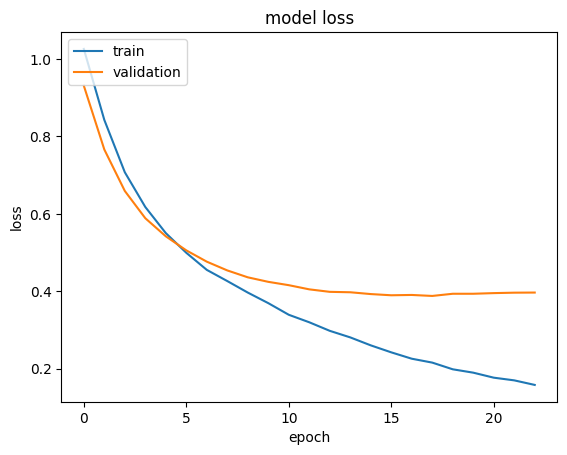

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss']) 
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show

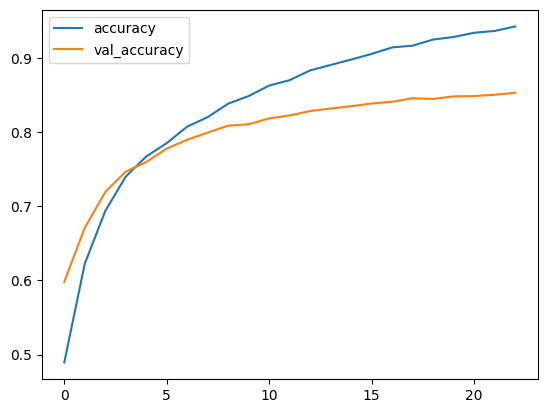

In [ ]:
plt.plot(history.history['accuracy'],label='accuracy')
plt.plot(history.history['val_accuracy'],label='val_accuracy')
plt.legend()

In [ ]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred,axis=1)
y_test_classes = np.argmax(y_test, axis=1)

266/266 ━━━━━━━━━━━━━━━━━━━━ 67s 238ms/step


In [ ]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score, confusion_matrix

<Axes: >

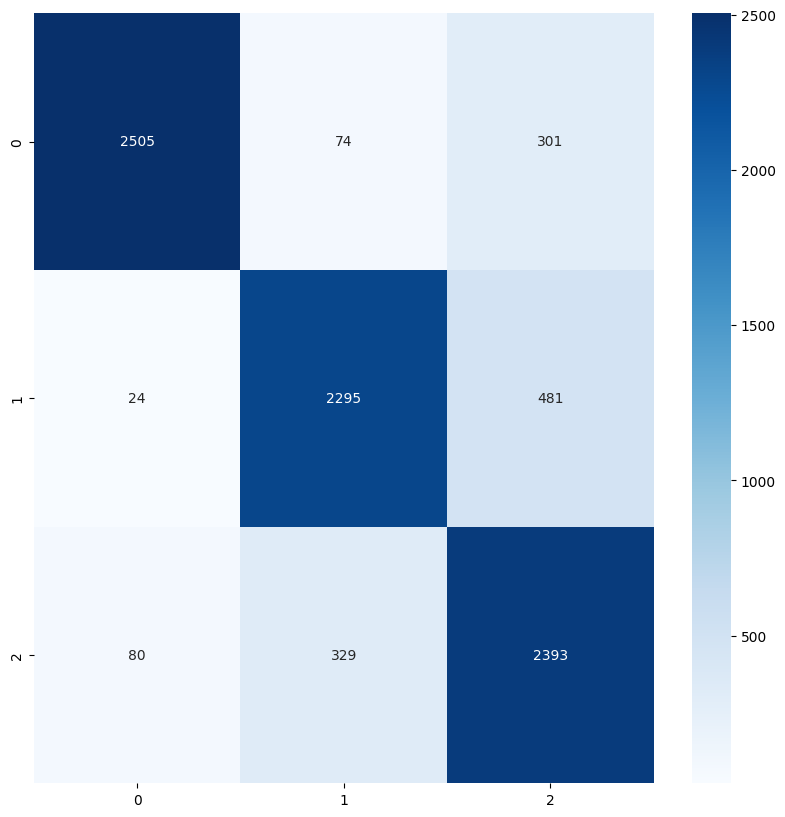

In [ ]:
import seaborn as sns
plt.figure(figsize=(10,10))
sns.heatmap(confusion_matrix(y_test_classes,y_pred_classes),annot=True,fmt='d',cmap='Blues')

In [43]:
print('Accuracy:',accuracy_score(y_test_classes,y_pred_classes))
print('Precision:',precision_score(y_test_classes,y_pred_classes,average='weighted'))
print('Recall:',recall_score(y_test_classes,y_pred_classes,average='weighted'))
print('F1 Score:',f1_score(y_test_classes,y_pred_classes,average='weighted'))
print('ROC AUC Score:',roc_auc_score(y_test_classes,y_pred,average='weighted', multi_class='ovr'))

Accuracy: 0.8480311247347324
Precision: 0.8557924156762702
Recall: 0.8480311247347324
F1 Score: 0.850025411549668
ROC AUC Score: 0.9610057948801086


In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

plt.figure(figsize=(10,10))

# Binarize the true labels for multi-class ROC
y_test_bin = label_binarize(y_test_classes, classes=np.unique(y_test_classes))
n_classes = y_test_bin.shape[1]

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve for each class
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

# Plot the diagonal line
plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.close()
plt.show()